In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd

# **1. Define Project**

 Project Title: Customer Churn Prediction

 Goal:
 Predict whether a customer will exit (churn) based on their profile information.

 Dataset:
 Dataset from Kaggle (Churn Prediction Dataset)

 Target Variable: Exited (1 = Churn, 0 = No Churn)

 Features include:
 - Demographics (Age, Gender, Geography)
 - Account Information (CreditScore, Balance, NumOfProducts, Tenure)
 - Behavior (HasCrCard, IsActiveMember)


# **2. Data Loading and Initial Look**

In [20]:
# Load training data
df = pd.read_csv('train.csv')


In [21]:
print("Training Data Shape:", df.shape)


Training Data Shape: (165034, 14)


In [22]:
df.head(10)

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15674932,Okwudilichukwu,668,France,Male,33.0,3,0.00,2,1.0,0.0,181449.97,0
1,1,15749177,Okwudiliolisa,627,France,Male,33.0,1,0.00,2,1.0,1.0,49503.50,0
2,2,15694510,Hsueh,678,France,Male,40.0,10,0.00,2,1.0,0.0,184866.69,0
3,3,15741417,Kao,581,France,Male,34.0,2,148882.54,1,1.0,1.0,84560.88,0
4,4,15766172,Chiemenam,716,Spain,Male,33.0,5,0.00,2,1.0,1.0,15068.83,0
5,5,15771669,Genovese,588,Germany,Male,36.0,4,131778.58,1,1.0,0.0,136024.31,1
6,6,15692819,Ch'ang,593,France,Female,30.0,8,144772.69,1,1.0,0.0,29792.11,0
7,7,15669611,Chukwuebuka,678,Spain,Male,37.0,1,138476.41,1,1.0,0.0,106851.60,0
8,8,15691707,Manna,676,France,Male,43.0,4,0.00,2,1.0,0.0,142917.13,0
9,9,15591721,Cattaneo,583,Germany,Male,40.0,4,81274.33,1,1.0,1.0,170843.07,0


In [23]:
# Columns
print("Columns:", df.columns.tolist())

# Summary statistics
print("Summary Statistics:")
print(df.describe())

# Count missing values per column
print("Missing Values per Column:")
print(df.isnull().sum())



Columns: ['id', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']
Summary Statistics:
                id    CustomerId    CreditScore            Age         Tenure  \
count  165034.0000  1.650340e+05  165034.000000  165034.000000  165034.000000   
mean    82516.5000  1.569201e+07     656.454373      38.125888       5.020353   
std     47641.3565  7.139782e+04      80.103340       8.867205       2.806159   
min         0.0000  1.556570e+07     350.000000      18.000000       0.000000   
25%     41258.2500  1.563314e+07     597.000000      32.000000       3.000000   
50%     82516.5000  1.569017e+07     659.000000      37.000000       5.000000   
75%    123774.7500  1.575682e+07     710.000000      42.000000       7.000000   
max    165033.0000  1.581569e+07     850.000000      92.000000      10.000000   

             Balance  NumOfProducts      HasCrCard  IsActiveMember

In [24]:
# Basic data types and feature types
feature_info = []

for col in df.columns:
    dtype = df[col].dtype
    num_missing = df[col].isnull().sum()

    if dtype == 'object':
        f_type = 'Categorical'
        unique_vals = df[col].unique()
        if len(unique_vals) > 5:
            values = f"Example: {unique_vals[:5]}"
        else:
            values = ', '.join(map(str, unique_vals))
    else:
        f_type = 'Numerical'
        values = f"Range: {df[col].min()} to {df[col].max()}"

    feature_info.append([col, f_type, values, num_missing])

# Create feature table
feature_table = pd.DataFrame(feature_info, columns=["Feature", "Type", "Values/Range", "Missing Values"])
print("\nFeature Summary Table:\n")
print(feature_table)

#  Outlier check: using basic thresholds
print("\nOutlier Observations:")

# For Age and CreditScore
print("Age over 100:", (df['Age'] > 100).sum(), "people")
print("CreditScore below 300:", (df['CreditScore'] < 300).sum(), "people")

#  Class imbalance check
print("\nClass distribution (target 'Exited'):\n")
print(df['Exited'].value_counts(normalize=True))

#  Define Outlier
print("\nDefinition of Outlier:")
print("An outlier is a data point that differs significantly from other observations.")
print("In practice, an outlier could be an extreme Age (e.g., >100 years old) or very low Credit Score (e.g., <300).")

# Identify Target
print("\nTarget Variable Info:")
print("Target: Exited")
print("Type: Classification (binary classification: 0 = Stay, 1 = Exit)")



Feature Summary Table:

            Feature         Type  \
0                id    Numerical   
1        CustomerId    Numerical   
2           Surname  Categorical   
3       CreditScore    Numerical   
4         Geography  Categorical   
5            Gender  Categorical   
6               Age    Numerical   
7            Tenure    Numerical   
8           Balance    Numerical   
9     NumOfProducts    Numerical   
10        HasCrCard    Numerical   
11   IsActiveMember    Numerical   
12  EstimatedSalary    Numerical   
13           Exited    Numerical   

                                         Values/Range  Missing Values  
0                                  Range: 0 to 165033               0  
1                         Range: 15565701 to 15815690               0  
2   Example: ['Okwudilichukwu' 'Okwudiliolisa' 'Hs...               0  
3                                   Range: 350 to 850               0  
4                              France, Spain, Germany               0  
5 

In [25]:
import pandas as pd
import numpy as np
from tabulate import tabulate


# Check missing values
missing_values = df.isnull().sum()

print("\nMissing Values per Column:\n")
print(tabulate(missing_values.reset_index().values, headers=["Feature", "Missing Values"], tablefmt="grid"))

# Build feature information table
feature_info = []

for col in df.columns:
    dtype = df[col].dtype
    num_missing = df[col].isnull().sum()

    if dtype == 'object':
        f_type = 'Categorical'
        unique_vals = df[col].unique()
        if len(unique_vals) > 5:
            values = f"Example: {unique_vals[:5]}"
        else:
            values = ', '.join(map(str, unique_vals))
    else:
        f_type = 'Numerical'
        values = f"Range: {df[col].min()} to {df[col].max()}"

    feature_info.append([col, f_type, values, num_missing])

#  Display the Feature Summary Table nicely
headers = ["Feature", "Type", "Values/Range", "Missing Values"]
print("\nFeature Summary Table:\n")
print(tabulate(feature_info, headers=headers, tablefmt="grid"))

#  Outlier check
print("\nOutlier Observations:")
print(f"Age > 100 years old: {(df['Age'] > 100).sum()} instances")
print(f"CreditScore < 300: {(df['CreditScore'] < 300).sum()} instances")

#  Class imbalance check
print("\nClass Distribution (Target 'Exited'):")
class_distribution = df['Exited'].value_counts(normalize=True) * 100
print(tabulate(class_distribution.reset_index().values, headers=["Exited", "Percentage"], tablefmt="grid"))

# Define Outlier
print("\nDefinition of Outlier:")
print("An outlier is a data point that significantly deviates from other observations.\n"
      "Examples: Age > 100 years old, CreditScore < 300, unusually high Balance, etc.")

#  Target Info
print("\nTarget Variable Information:")
print("Target = 'Exited'")
print("Type = Classification Problem (Binary Classification: 0 = Stayed, 1 = Exited)")



Missing Values per Column:

+-----------------+------------------+
| Feature         |   Missing Values |
+=================+==================+
| id              |                0 |
+-----------------+------------------+
| CustomerId      |                0 |
+-----------------+------------------+
| Surname         |                0 |
+-----------------+------------------+
| CreditScore     |                0 |
+-----------------+------------------+
| Geography       |                0 |
+-----------------+------------------+
| Gender          |                0 |
+-----------------+------------------+
| Age             |                0 |
+-----------------+------------------+
| Tenure          |                0 |
+-----------------+------------------+
| Balance         |                0 |
+-----------------+------------------+
| NumOfProducts   |                0 |
+-----------------+------------------+
| HasCrCard       |                0 |
+-----------------+----------------

# **3. Data Visualization (Numerical)**

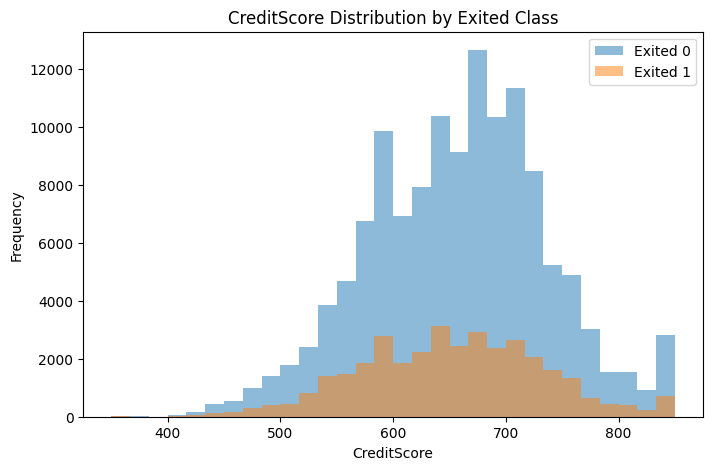

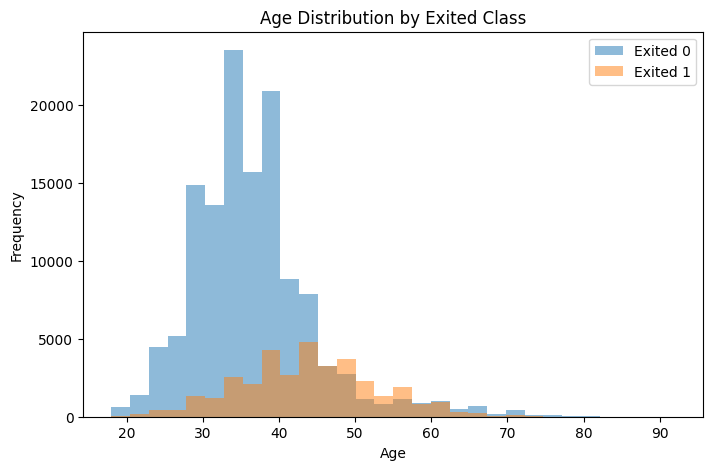

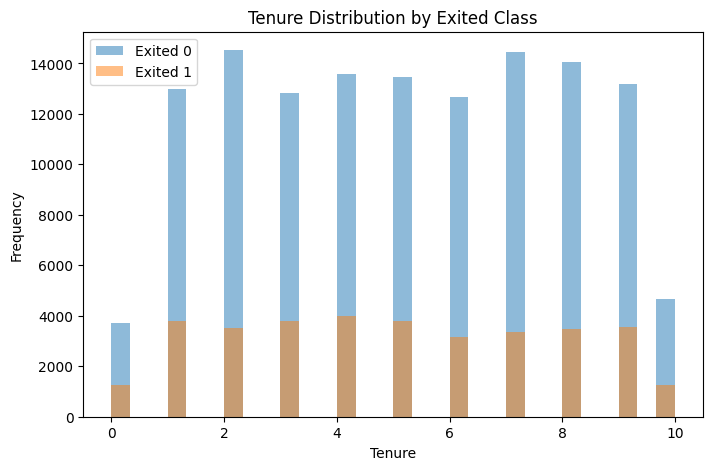

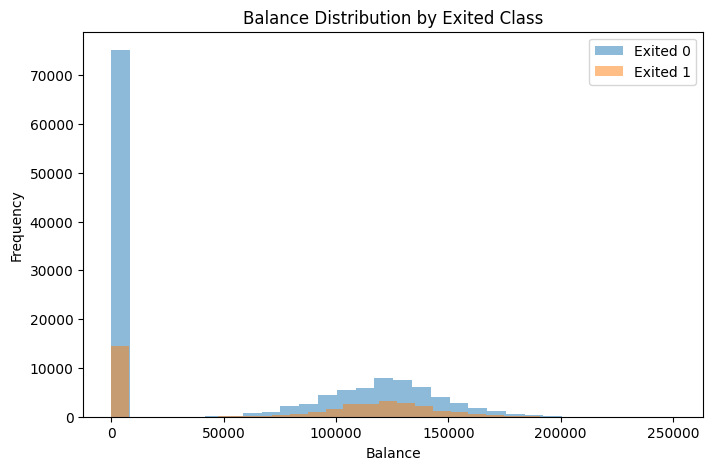

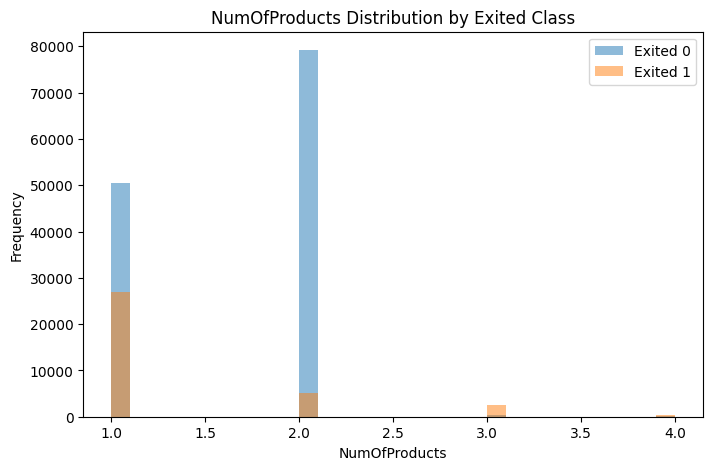

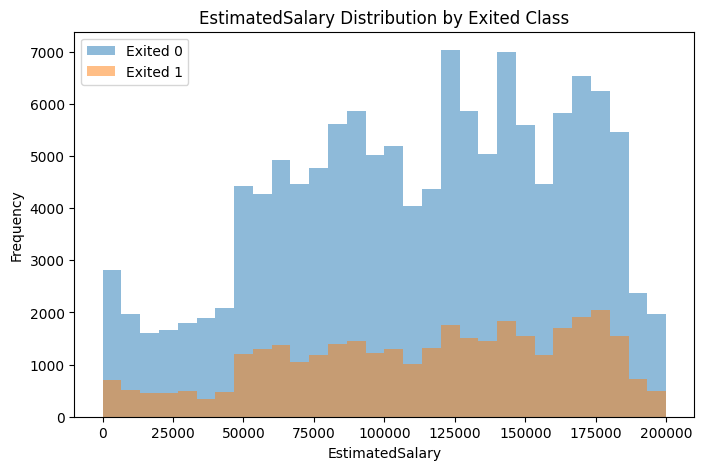

In [26]:
import matplotlib.pyplot as plt
# Before Normalization
# List of numerical columns
numerical_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

for col in numerical_cols:
    plt.figure(figsize=(8, 5))

    for target_class in df['Exited'].unique():
        df[df['Exited'] == target_class][col].plot(
            kind='hist',
            bins=30,
            alpha=0.5,
            label=f'Exited {target_class}'
        )

    plt.legend()
    plt.title(f'{col} Distribution by Exited Class')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(False)
    plt.show()


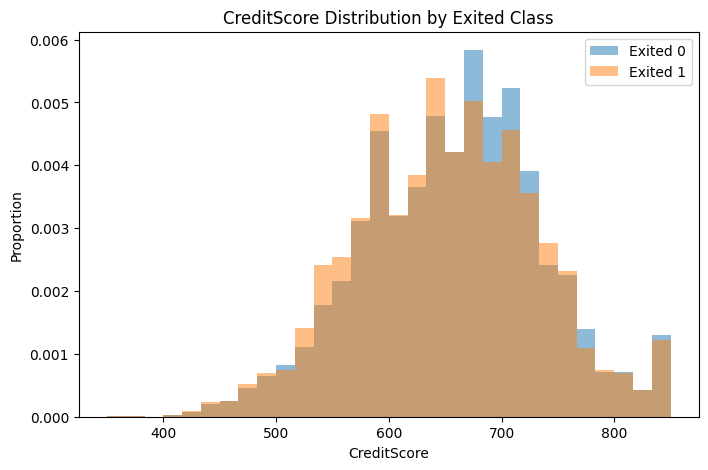

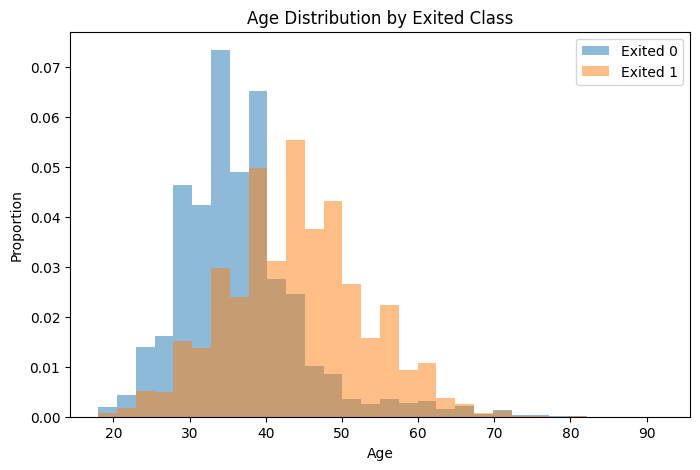

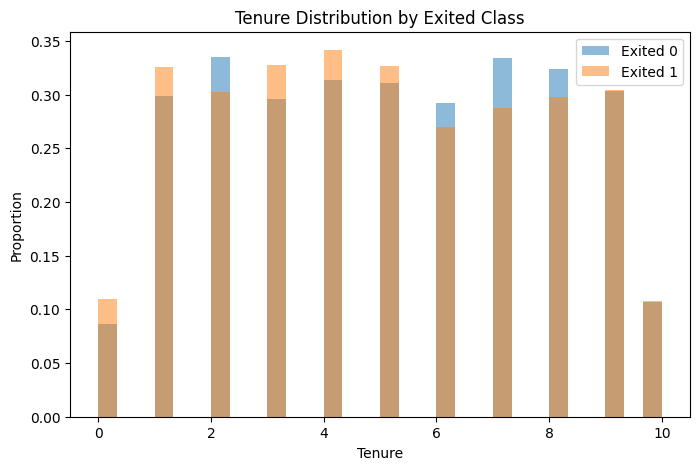

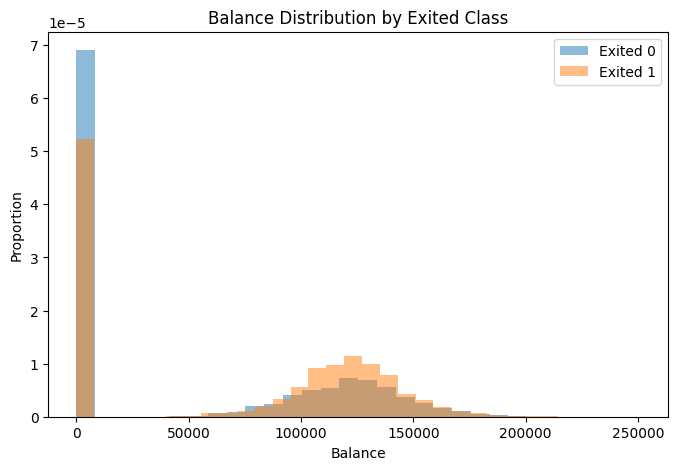

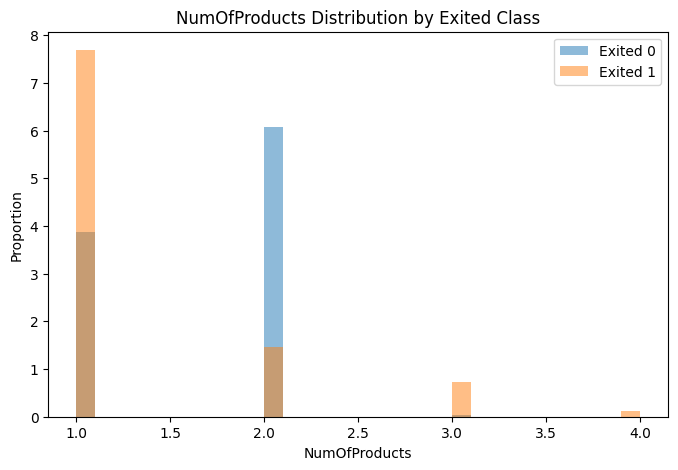

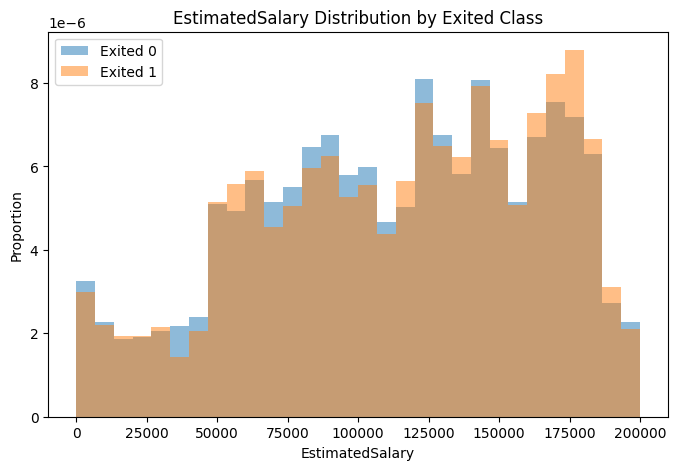

In [27]:
# List of numerical columns
# After Normalization

numerical_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

for col in numerical_cols:
    plt.figure(figsize=(8, 5))

    for target_class in df['Exited'].unique():
        df[df['Exited'] == target_class][col].plot(
            kind='hist',
            bins=30,
            alpha=0.5,
            density=True,  # normalize the histogram
            label=f'Exited {target_class}'
        )

    plt.legend()
    plt.title(f'{col} Distribution by Exited Class')
    plt.xlabel(col)
    plt.ylabel('Proportion')
    plt.grid(False)
    plt.show()


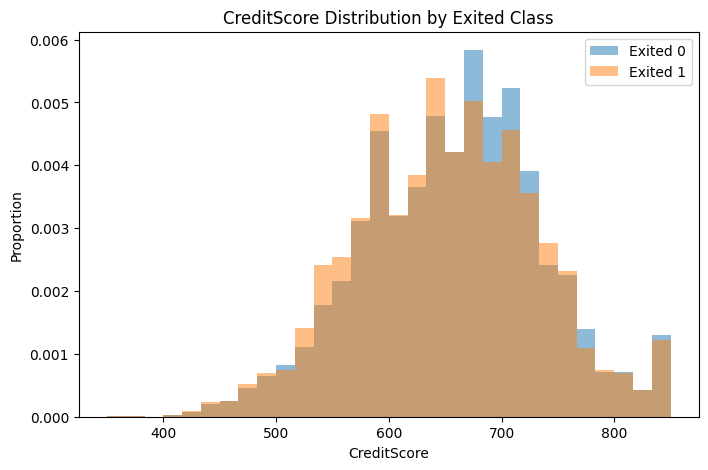

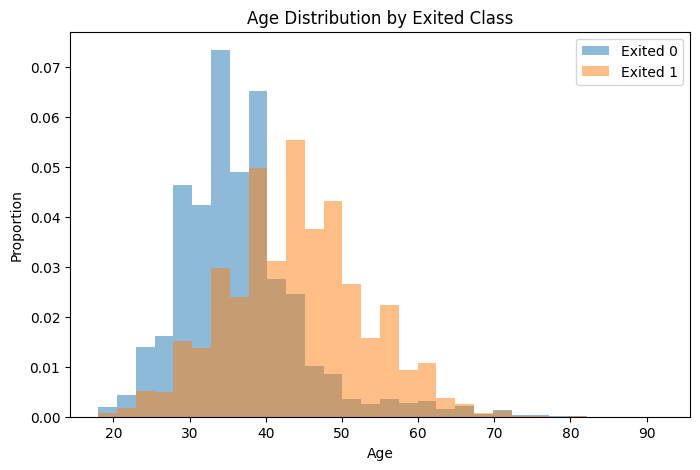

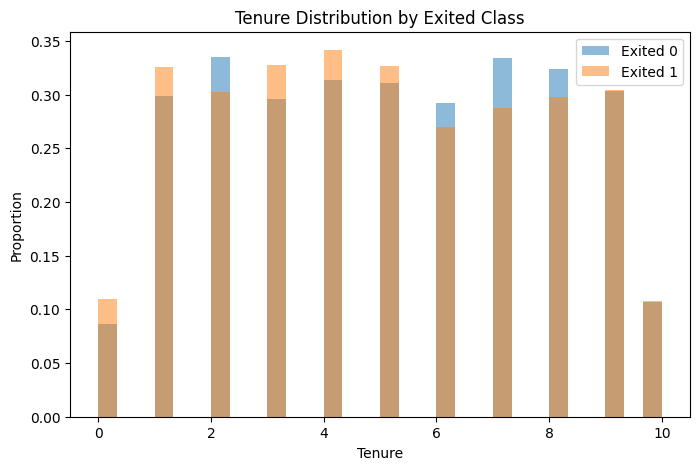

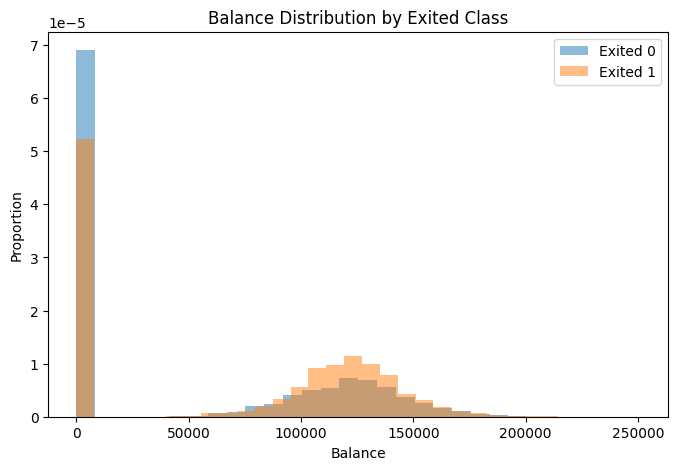

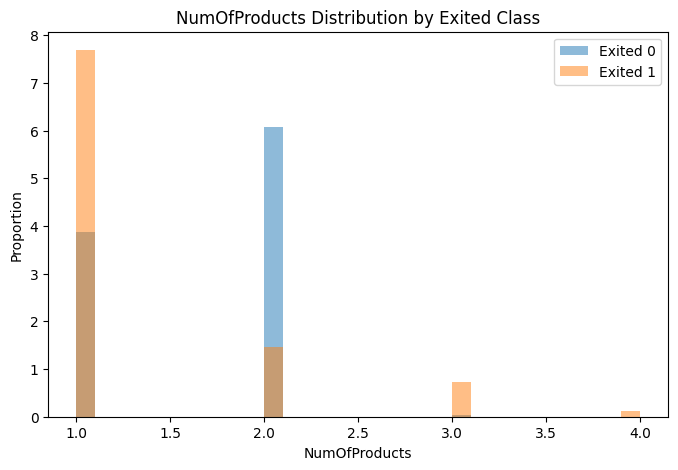

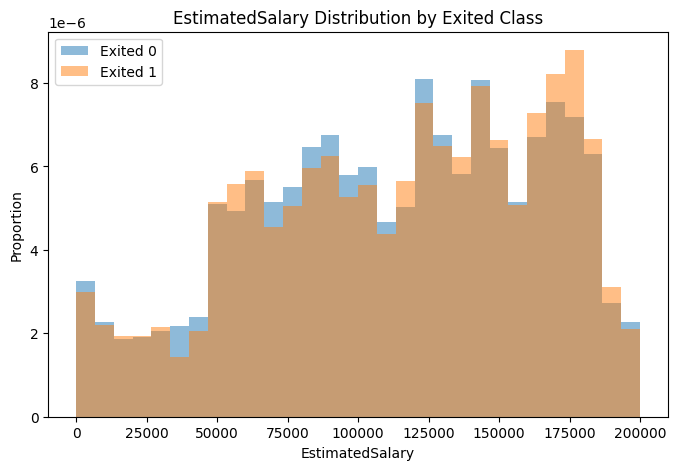

In [28]:
import matplotlib.pyplot as plt

# List of numerical columns
numerical_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

# Plot normalized histograms for each numerical feature
for col in numerical_cols:
    plt.figure(figsize=(8, 5))

    for target_class in df['Exited'].unique():
        df[df['Exited'] == target_class][col].plot(
            kind='hist',
            bins=30,
            alpha=0.5,
            density=True,  # normalize the histogram
            label=f'Exited {target_class}'
        )

    plt.legend()
    plt.title(f'{col} Distribution by Exited Class')
    plt.xlabel(col)
    plt.ylabel('Proportion')
    plt.grid(False)
    plt.show()


# **3. Data Visualization (Categorical)**

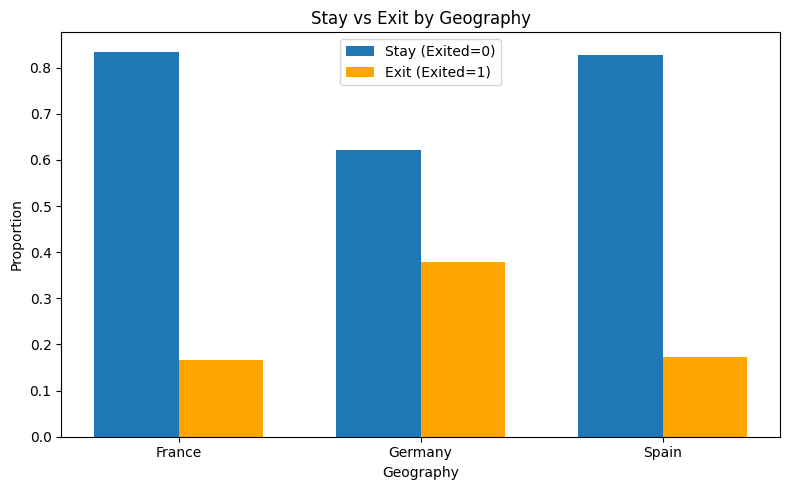

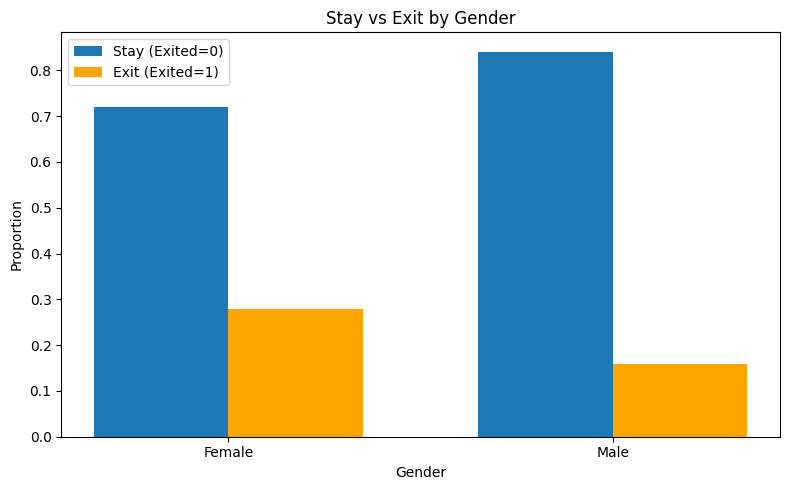

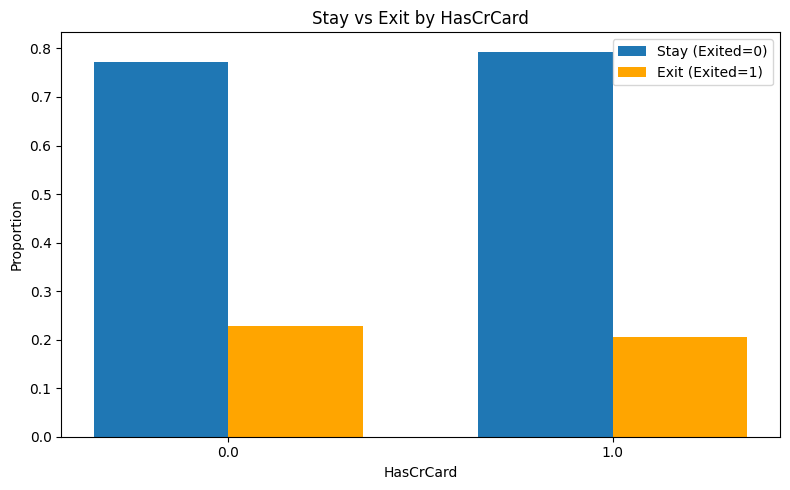

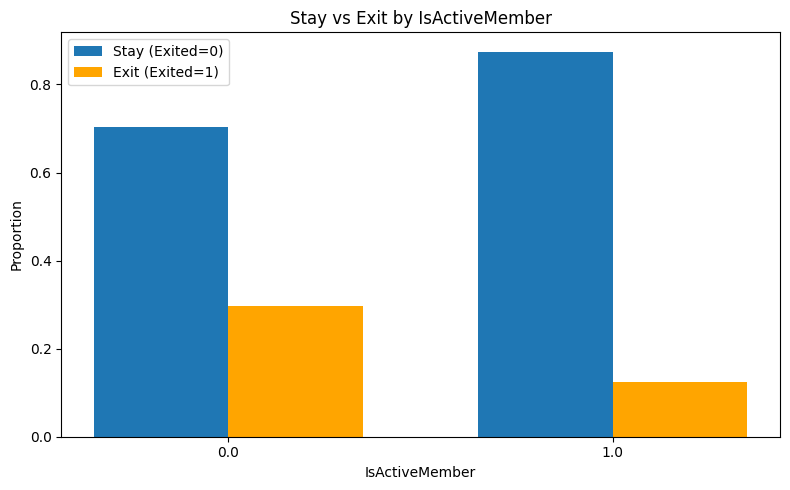

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# Categorical Features
# Categorical Columns
categorical_cols = ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember']

for col in categorical_cols:
    plt.figure(figsize=(8, 5))

    crosstab = pd.crosstab(df[col], df['Exited'], normalize='index')

    labels = crosstab.index
    stay = crosstab[0]  # Stay %
    exit_ = crosstab[1] # Exit %

    x = np.arange(len(labels))
    width = 0.35

    plt.bar(x - width/2, stay, width=width, label='Stay (Exited=0)')
    plt.bar(x + width/2, exit_, width=width, label='Exit (Exited=1)', color='orange')

    plt.xlabel(col)
    plt.ylabel('Proportion')
    plt.title(f'Stay vs Exit by {col}')
    plt.xticks(x, labels, rotation=0)
    plt.legend()
    plt.grid(False)
    plt.tight_layout()
    plt.show()


# **4.Data Cleaning and Preperation for Machine Learning**

In [30]:
from sklearn.preprocessing import StandardScaler

# Drop unneeded columns
# CustomerId, Surname, id are identifiers --> drop them
df = df.drop(['id', 'CustomerId', 'Surname'], axis=1)

# One-hot encode categorical features
# Geography and Gender are categorical
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)

# Rescale numerical features
numerical_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# Preview cleaned data
print(df.head())


   CreditScore       Age    Tenure   Balance  NumOfProducts  HasCrCard  \
0     0.144135 -0.578074 -0.719973 -0.883163       0.814298        1.0   
1    -0.367706 -0.578074 -1.432694 -0.883163       0.814298        1.0   
2     0.268974  0.211354  1.774548 -0.883163       0.814298        1.0   
3    -0.941966 -0.465299 -1.076334  1.486918      -1.013348        1.0   
4     0.743362 -0.578074 -0.007253 -0.883163       0.814298        1.0   

   IsActiveMember  EstimatedSalary  Exited  Geography_Germany  \
0             0.0         1.369486       0              False   
1             1.0        -1.254085       0              False   
2             0.0         1.437422       0              False   
3             1.0        -0.557018       0              False   
4             1.0        -1.938770       0              False   

   Geography_Spain  Gender_Male  
0            False         True  
1            False         True  
2            False         True  
3            False         T

# **5.Machine Learning**

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Define X (features) and y (target)
X = df.drop('Exited', axis=1)
y = df['Exited']

# Split data
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train a Random Forest Classifier
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_val)

print("Validation Accuracy:", accuracy_score(y_val, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred))
print("Classification Report:\n", classification_report(y_val, y_pred))


Validation Accuracy: 0.8582421910503832
Confusion Matrix:
 [[24601  1422]
 [ 3257  3727]]
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.95      0.91     26023
           1       0.72      0.53      0.61      6984

    accuracy                           0.86     33007
   macro avg       0.80      0.74      0.76     33007
weighted avg       0.85      0.86      0.85     33007



In [32]:
from sklearn.metrics import roc_curve, auc, precision_score, recall_score, f1_score, accuracy_score
from tabulate import tabulate
import numpy as np

# Predictions and scores
y_true = y_val  # true labels from validation set
y_scores = model.predict_proba(X_val)[:, 1]
y_pred = model.predict(X_val)

# ROC curve & AUC
fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

# Other metrics (threshold = 0.5)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
accuracy = accuracy_score(y_true, y_pred)

# Maximal significance (σₛ at threshold 0.9)
threshold = 0.9
selected = y_scores > threshold
N_S = ((y_true == 1) & selected).sum()
N_B = ((y_true == 0) & selected).sum()
sigma = N_S / np.sqrt(N_S + N_B) if (N_S + N_B) > 0 else 0

# Display the results
headers = ["Metric", "Value"]
data = [
    ["AUC", f"{roc_auc:.3f}"],
    ["Precision", f"{precision:.3f}"],
    ["Recall (TPR)", f"{recall:.3f}"],
    ["Accuracy", f"{accuracy:.3f}"],
    ["F1 Score", f"{f1:.3f}"],
    ["Max Significance (σₛ)", f"{sigma:.2f} (at threshold = {threshold})"]
]

print(tabulate(data, headers=headers, tablefmt="grid"))


+-----------------------+----------------------------+
| Metric                | Value                      |
+=======================+============================+
| AUC                   | 0.872                      |
+-----------------------+----------------------------+
| Precision             | 0.724                      |
+-----------------------+----------------------------+
| Recall (TPR)          | 0.534                      |
+-----------------------+----------------------------+
| Accuracy              | 0.858                      |
+-----------------------+----------------------------+
| F1 Score              | 0.614                      |
+-----------------------+----------------------------+
| Max Significance (σₛ) | 29.22 (at threshold = 0.9) |
+-----------------------+----------------------------+


In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

#Train Logistic Regression
logreg_model = LogisticRegression(max_iter=1000, random_state=42)
logreg_model.fit(X_train, y_train)

y_pred_logreg = logreg_model.predict(X_val)

accuracy_logreg = accuracy_score(y_val, y_pred_logreg)
precision_logreg = precision_score(y_val, y_pred_logreg)
recall_logreg = recall_score(y_val, y_pred_logreg)
f1_logreg = f1_score(y_val, y_pred_logreg)

print("Logistic Regression Performance:")
print(f"Accuracy: {accuracy_logreg:.3f}")
print(f"Precision: {precision_logreg:.3f}")
print(f"Recall: {recall_logreg:.3f}")
print(f"F1 Score: {f1_logreg:.3f}")


Logistic Regression Performance:
Accuracy: 0.833
Precision: 0.693
Recall: 0.381
F1 Score: 0.492


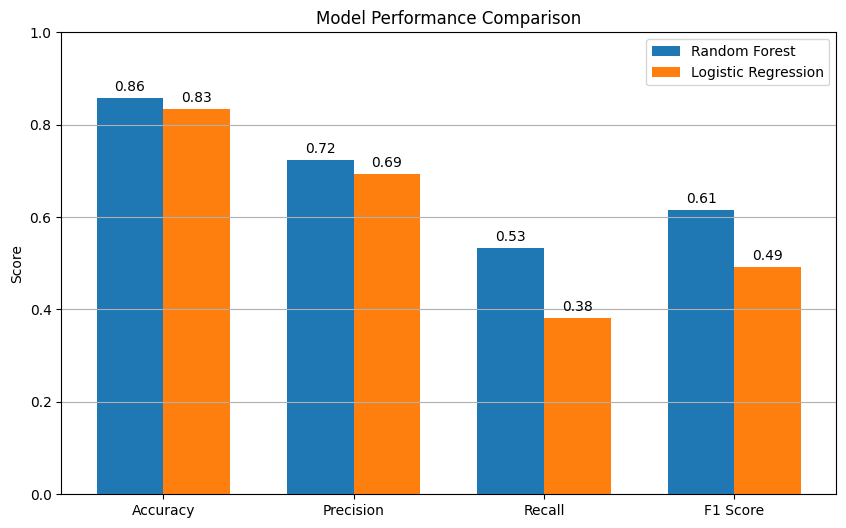

In [38]:
import matplotlib.pyplot as plt
import numpy as np

# Metrics from Random Forest (first model) ---
y_pred_rf = model.predict(X_val)

accuracy_rf = accuracy_score(y_val, y_pred_rf)
precision_rf = precision_score(y_val, y_pred_rf)
recall_rf = recall_score(y_val, y_pred_rf)
f1_rf = f1_score(y_val, y_pred_rf)

# Metrics from Logistic Regression (second model)
accuracy_logreg = accuracy_score(y_val, y_pred_logreg)
precision_logreg = precision_score(y_val, y_pred_logreg)
recall_logreg = recall_score(y_val, y_pred_logreg)
f1_logreg = f1_score(y_val, y_pred_logreg)

# Comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
rf_scores = [accuracy_rf, precision_rf, recall_rf, f1_rf]
logreg_scores = [accuracy_logreg, precision_logreg, recall_logreg, f1_logreg]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10,6))
rects1 = ax.bar(x - width/2, rf_scores, width, label='Random Forest')
rects2 = ax.bar(x + width/2, logreg_scores, width, label='Logistic Regression')

# Labels and Titles
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1)
ax.legend()

# Value labels on bars
def add_labels(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

add_labels(rects1)
add_labels(rects2)

plt.grid(axis='y')
plt.show()


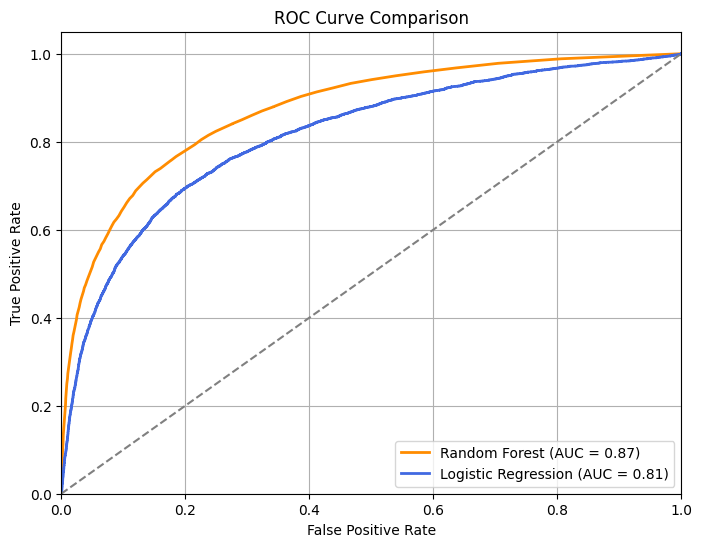

In [40]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# --- Random Forest ---
rf_probs = model.predict_proba(X_val)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_val, rf_probs)
auc_rf = auc(fpr_rf, tpr_rf)

# --- Logistic Regression ---
logreg_probs = logreg_model.predict_proba(X_val)[:, 1]
fpr_log, tpr_log, _ = roc_curve(y_val, logreg_probs)
auc_log = auc(fpr_log, tpr_log)

# --- Both ROC curves ---
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='darkorange', lw=2, label=f'Random Forest (AUC = {auc_rf:.2f})')
plt.plot(fpr_log, tpr_log, color='royalblue', lw=2, label=f'Logistic Regression (AUC = {auc_log:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [35]:
# Load test data
test_data = pd.read_csv('test.csv')

test_ids = test_data['id']

# Same cleaning: drop id columns
test_data = test_data.drop(['id', 'CustomerId', 'Surname'], axis=1)

# One-hot encode
test_data = pd.get_dummies(test_data, columns=['Geography', 'Gender'], drop_first=True)

# Scale numerical
test_data[numerical_cols] = scaler.transform(test_data[numerical_cols])

# Predict
test_preds = model.predict(test_data)

# Create submission file
submission = pd.DataFrame({'id': test_ids, 'Exited': test_preds})
submission.to_csv('submission.csv', index=False)
